# IEEE 14 - Otimização Por Método de Pontos Interiores

Neste relatório, foi implementado o Método de Pontos Interiores através do pacote de Otimização GEKKO, utilizando-se o solver IPOPT. 

## IEEE 14:

- Caso de Estudo 1: Realiza o cálculo supondo que todas as variáveis são contínuas (solução não-factível);

- Caso de Estudo 2: Realiza o cálculo supondo que todas as variáveis são contínuas e, ao final da solução, as variáveis discretas são arredondadas para o valor mais próximo do conjunto discreto permitido (factível);


As funções desenvolvidas para lidar com os dados e com a formulação matemática do problema foram importadas do arquivo msc_rafael_pavan.py, de modo a deixar o relatório mais consciso.

In [1]:
# Importa packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandapower as pp
import time
import random
from pandapower.networks import case14, case_ieee30, case118, case300, case4gs
import tabulate
import numba
from numba import njit
from gekko import GEKKO
from pandapower.plotting.plotly import pf_res_plotly
import pandapower.plotting as pplot
plt.style.use('fivethirtyeight')

%matplotlib inline
plt.rcParams['figure.figsize'] = (20.0, 10.0)
plt.rcParams['font.family'] = "serif"
font = {'size'   : 15}
plt.rc('font', **font)
plt.rc('xtick', labelsize=15) 
plt.rc('ytick', labelsize=15) 

In [2]:
# Importa funções desenvolvidas

from msc_rafael_pavan import inicializa_sep
from msc_rafael_pavan import matriz_condutancia
from msc_rafael_pavan import coleta_dados_vbus
from msc_rafael_pavan import coleta_dados_gen
from msc_rafael_pavan import func_objetivo
from msc_rafael_pavan import pen_tensao
from msc_rafael_pavan import pen_ger_reativo
from msc_rafael_pavan import coleta_dados_trafo
from msc_rafael_pavan import pen_trafo
from msc_rafael_pavan import coleta_dados_bshunt
from msc_rafael_pavan import converte_trafo
from msc_rafael_pavan import cria_alcateia
from msc_rafael_pavan import cria_enxame
from msc_rafael_pavan import pen_bshunt
from msc_rafael_pavan import fluxo_de_pot
from msc_rafael_pavan import fitness
from msc_rafael_pavan import validacao
from msc_rafael_pavan import otimizacao_gwo_continuo
from msc_rafael_pavan import otimizacao_pso_continuo
from msc_rafael_pavan import discreto_bshunt
from msc_rafael_pavan import discreto_tap
from msc_rafael_pavan import otimizacao_gwo_discreto
from msc_rafael_pavan import otimizacao_pso_discreto
from msc_rafael_pavan import ipm_ieee30
from msc_rafael_pavan import ipm_ieee14

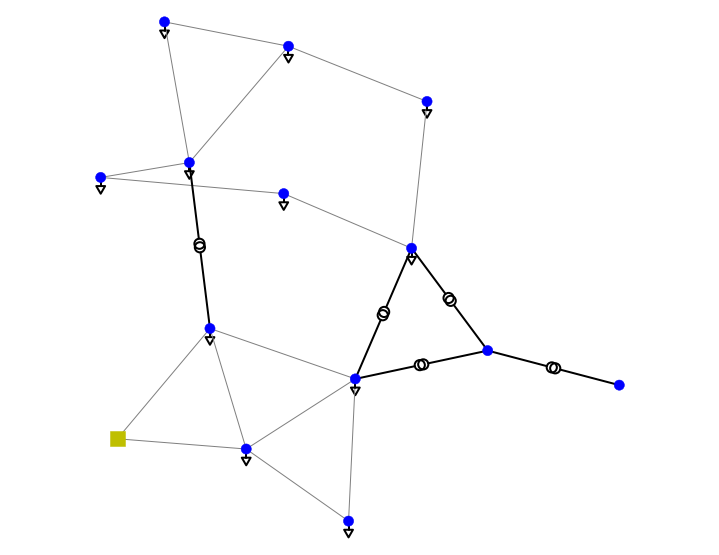

In [3]:
sep14 = case14()
pplot.simple_plot(sep14,plot_loads=True)

In [4]:
inicializa_sep(sep14,algorithm='nr', relatorio=False)

array([[1.045, 1.01 , 1.07 , 1.09 , 0.978, 0.969, 0.932, 0.19 , 0.   ,
        0.   , 0.   , 0.   , 0.   , 0.   ]])

# IPM Contínuo - IEEE 14

In [5]:
solucao_continua = ipm_ieee14(sep14, solver = 3, rtol = 1e-10, otol = 1e-10, max_iter = 100, relatorio = True, remoto = True, arredondado = False, travado = False)

apm 200.158.193.107_gk_model1 <br><pre> ----------------------------------------------------------------
 APMonitor, Version 1.0.0
 APMonitor Optimization Suite
 ----------------------------------------------------------------
 
 
 --------- APM Model Size ------------
 Each time step contains
   Objects      :            0
   Constants    :            0
   Variables    :           36
   Intermediates:            0
   Connections  :            0
   Equations    :           29
   Residuals    :           29
 
 Number of state variables:             36
 Number of total equations: -           28
 Number of slack variables: -            0
 ---------------------------------------
 Degrees of freedom       :              8
 
 **********************************************
 Steady State Optimization with Interior Point Solver
 **********************************************
  
  
 Info: Exact Hessian

******************************************************************************
This program c

In [6]:
validacao(sep14,solucao_continua)

Perdas de Potência Ativa [PU]:

0.13685971273809042
 
Penalização de Violação de Tensão [PU]:

4.5474735173349706e-15
 
Penalização de Violação de Geração de Reativo [PU]:

0.0
 
Penalização de Violação de TAP Discreto [PU]:

0.5847878199962423
 
Penalização de Violação de Bshunt Discreto [PU]:

0.003791613493538819
 


In [7]:
print(np.round(solucao_continua,5))

[1.02546 0.99505 1.05    1.01248 1.03447 0.9     0.97048 0.39   ]


# IPM Arredondado - IEEE 14

In [8]:
solucao_discreta = ipm_ieee14(sep14, solver = 3, rtol = 1e-10, otol = 1e-10, max_iter = 100, relatorio = True, remoto = True, arredondado = True, travado = False)

apm 200.158.193.107_gk_model3 <br><pre> ----------------------------------------------------------------
 APMonitor, Version 1.0.0
 APMonitor Optimization Suite
 ----------------------------------------------------------------
 
 
 --------- APM Model Size ------------
 Each time step contains
   Objects      :            0
   Constants    :            0
   Variables    :           36
   Intermediates:            0
   Connections  :            0
   Equations    :           29
   Residuals    :           29
 
 Number of state variables:             36
 Number of total equations: -           28
 Number of slack variables: -            0
 ---------------------------------------
 Degrees of freedom       :              8
 
 **********************************************
 Steady State Optimization with Interior Point Solver
 **********************************************
  
  
 Info: Exact Hessian

******************************************************************************
This program c

In [9]:
validacao(sep14,np.round(solucao_discreta,5))

Perdas de Potência Ativa [PU]:

0.13687193270781262
 
Penalização de Violação de Tensão [PU]:

4.5474735173349706e-15
 
Penalização de Violação de Geração de Reativo [PU]:

0.0
 
Penalização de Violação de TAP Discreto [PU]:

6.61188214432007e-27
 
Penalização de Violação de Bshunt Discreto [PU]:

1.3378069303703434e-26
 


In [10]:
print(np.round(solucao_discreta,5))

[1.02546 0.99505 1.05    1.01248 1.0375  0.9     0.96875 0.39   ]


Text(0.5, 1.0, 'Perdas de Potência Ativa [MW]')

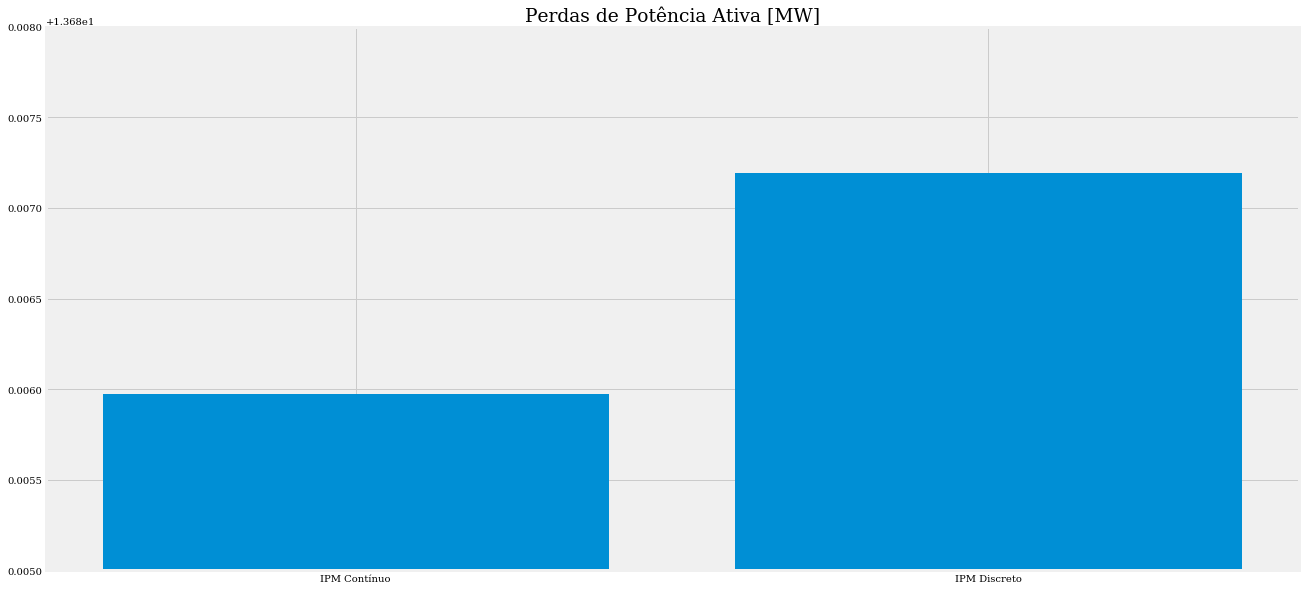

In [11]:
x14 = ['IPM Contínuo', 'IPM Discreto']
y14 = [np.round(13.685971273809042,10), np.round(13.68719327073133,10)]

plt.bar(x14,y14)
plt.ylim((13.685, 13.688))
plt.title('Perdas de Potência Ativa [MW]')

In [12]:
dif_absoluta = y14[0]-y14[1]
dif_percentual = ((y14[0]-y14[1])/y14[0])

print('Perdas IPM Contínuo IEEE 14 [MW]:', y14[0],'\n')

print('Perdas IPM Arredondado IEEE 14 [MW]:', y14[1],'\n')

print('Diferença Absoluta IEEE 14 [MW]:', np.round(np.abs(dif_absoluta),6),'\n')

print('Diferença Absoluta IEEE 14 [%]:', np.abs(np.round(dif_percentual*100,6)),'\n')

Perdas IPM Contínuo IEEE 14 [MW]: 13.6859712738 

Perdas IPM Arredondado IEEE 14 [MW]: 13.6871932707 

Diferença Absoluta IEEE 14 [MW]: 0.001222 

Diferença Absoluta IEEE 14 [%]: 0.008929 



In [13]:
solucoes_ieee14 = {'IEEE_14_discreta':solucao_discreta, 'IEEE_14_continua':solucao_continua}

In [14]:
solucoes_ieee14

{'IEEE_14_discreta': array([1.02545954, 0.99505426, 1.05      , 1.01248047, 1.0375    ,
        0.9       , 0.96875   , 0.38999975]),
 'IEEE_14_continua': array([1.02545954, 0.99505426, 1.05      , 1.01248047, 1.03447063,
        0.9000005 , 0.970482  , 0.38999975])}

In [15]:
solucoes_ieee14 = pd.DataFrame(solucoes_ieee14)

In [16]:
solucoes_ieee14.head(10)

,IEEE_14_discreta,IEEE_14_continua
0,1.025460,1.025460
1,0.995054,0.995054
2,1.050000,1.050000
3,1.012480,1.012480
4,1.037500,1.034471
5,0.900000,0.900000
6,0.968750,0.970482
7,0.390000,0.390000


In [17]:
solucoes_ieee14.to_csv('ipm_ieee14.csv',sep=';')

# Solução Arredondada (Factível)

+---------------------------+--------------------------+----------------------+----------------------+
|   Tensões nas Barras (pu) |   Ângulos das Barras (°) |   Limites Inferiores |   Limites Superiores |
|---------------------------+--------------------------+----------------------+----------------------|
|                   1.05    |                  0       |                 0.95 |                 1.05 |
|                   1.02546 |                 -4.94898 |                 0.95 |                 1.05 |
|                   0.99505 |                -13.0262  |                 0.95 |                 1.05 |
|                   1.00387 |                -10.5588  |                 0.95 |                 1.05 |
|                   1.00915 |                 -9.01066 |                 0.95 |                 1.05 |
|                   1.05    |                -14.7015  |                 0.95 |                 1.05 |
|                   1.01592 |                -13.8749  |                 

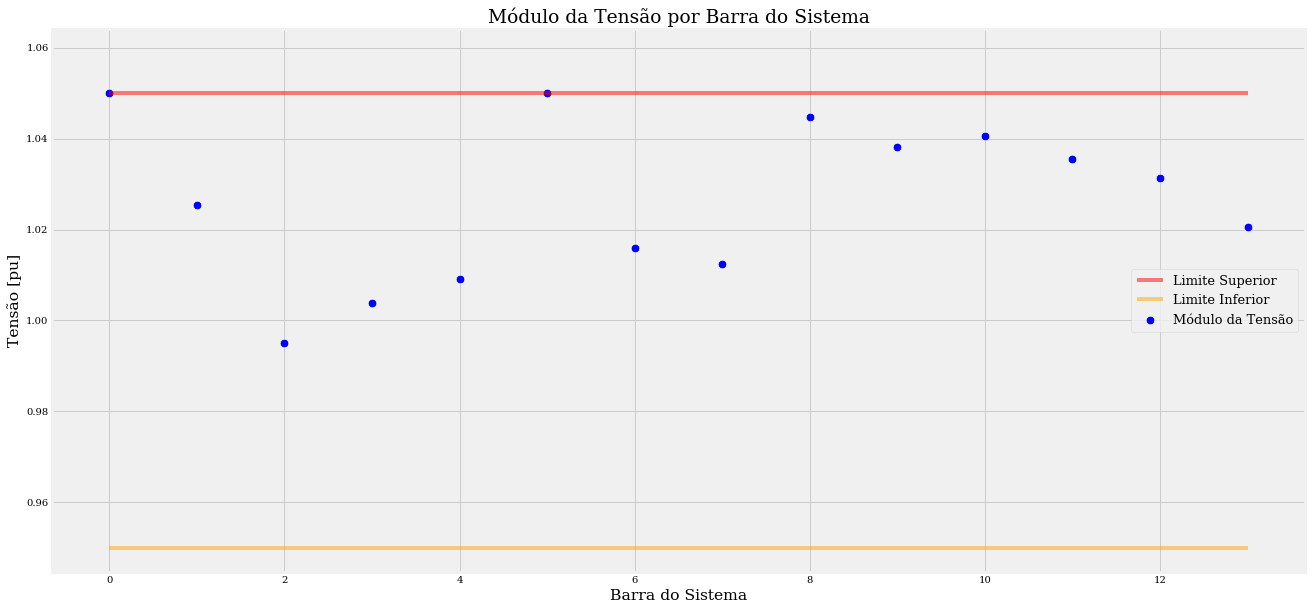

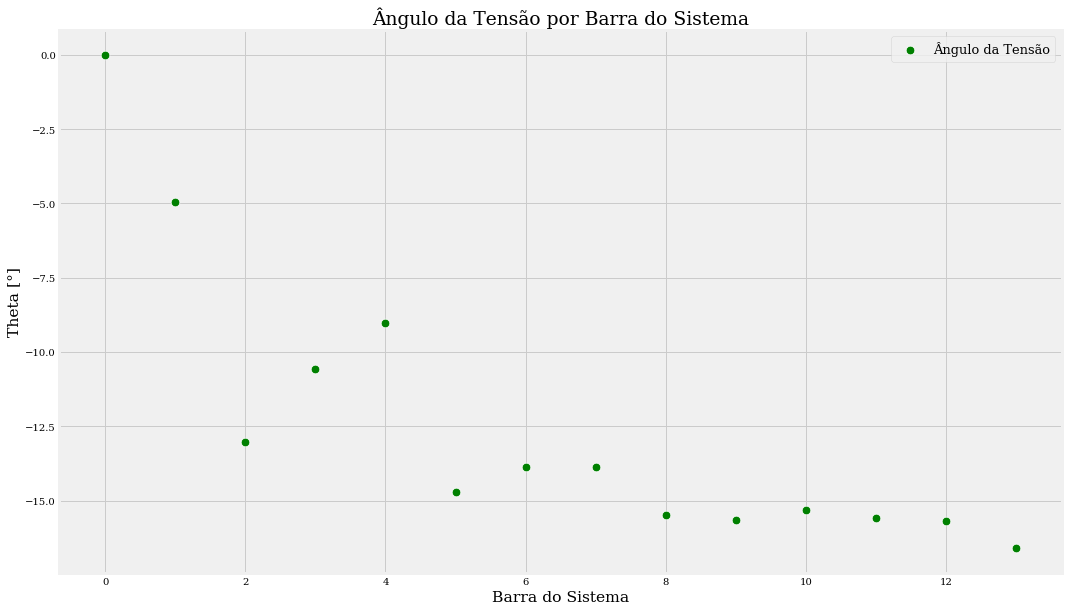

In [18]:
coleta_dados_vbus(sep14,relatorio=True)


+----------+--------------------+--------------------+-----------+--------------------+--------------------+
|   P (pu) |   P Lim. Sup. (pu) |   P Lim. Inf. (pu) |    Q (pu) |   Q Lim. Sup. (pu) |   Q Lim. Inf. (pu) |
|----------+--------------------+--------------------+-----------+--------------------+--------------------|
|      0.4 |                1.4 |                  0 |  0.160981 |               0.5  |              -0.4  |
|      0   |                1   |                  0 |  0.274045 |               0.4  |               0    |
|      0   |                1   |                  0 |  0.235084 |               0.24 |              -0.06 |
|      0   |                1   |                  0 | -0.01975  |               0.24 |              -0.06 |
+----------+--------------------+--------------------+-----------+--------------------+--------------------+


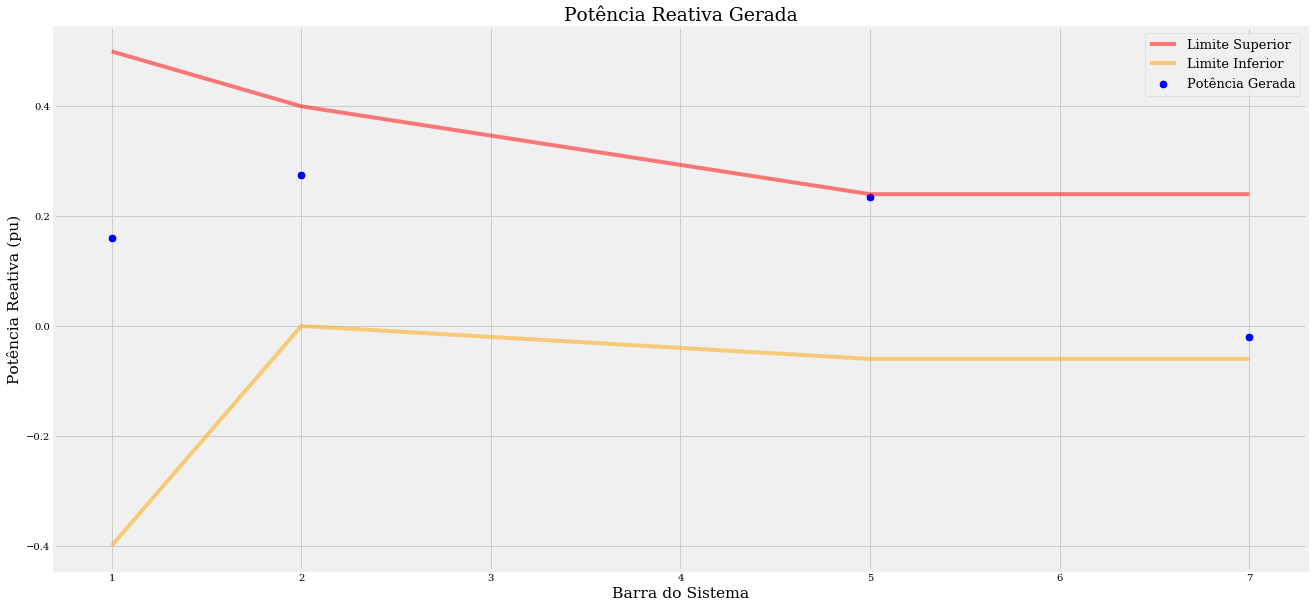

In [19]:
coleta_dados_gen(sep14,relatorio=True)